# 07 - Treino DistilBERT (PyTorch)

Fine-tuning do DistilBERT para classificação de texto.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Optuna com 20 trials


In [23]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [24]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader

from src.hyperopt import create_study, study_results_dataframe, suggest_params
from src.models_pytorch.distilbert import DistilBERTClassifier, DistilBERTDataset, get_tokenizer


In [25]:
# Configuração
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
N_TRIALS = 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL'] = '1'

print(f'Device: {DEVICE}')


Device: cuda


## 1. Carregamento de Dados

In [26]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    return df


df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')


Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
Train: 2566 amostras
  Labels: {'Human': 567, 'Meta': 555, 'Google': 525, 'Anthropic': 488, 'OpenAI': 431}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


In [27]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_train['Text'].tolist(),
    df_train['label_id'].values,
    test_size=0.2,
    random_state=SEED,
    stratify=df_train['label_id'].values,
)

print(f'Train interno: {len(train_texts)}')
print(f'Val interno: {len(val_texts)}')


Train interno: 2052
Val interno: 514


## 2. Tokenizer

In [28]:
print('Carregando tokenizer DistilBERT...')
tokenizer = get_tokenizer()
print('Tokenizer carregado.')


Carregando tokenizer DistilBERT...
Tokenizer carregado.


## 3. Funções de Treino

In [29]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labs = batch['label'].to(device)

        optimizer.zero_grad()
        out = model(input_ids, attention_mask)
        loss = criterion(out, labs)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(labs)
        correct += (out.argmax(dim=1) == labs).sum().item()
        total += len(labs)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            out = model(input_ids, attention_mask)
            loss = criterion(out, labs)
            total_loss += loss.item() * len(labs)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return total_loss / total, correct / total


def train_bert(params, train_texts, train_labels, val_texts, val_labels, tokenizer, device):
    train_ds = DistilBERTDataset(train_texts, train_labels, tokenizer, max_len=params['max_len'])
    val_ds = DistilBERTDataset(val_texts, val_labels, tokenizer, max_len=params['max_len'])

    train_dl = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=params['batch_size'])

    model = DistilBERTClassifier(
        output_dim=NUM_CLASSES,
        dropout=params['dropout'],
        freeze_bert=params.get('freeze_bert', False),
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params.get('weight_decay', 0.01),
    )

    best_val_acc = -1.0
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    t0 = time.time()
    for epoch in range(params['epochs']):
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion, device)
        vl_loss, vl_acc = eval_epoch(model, val_dl, criterion, device)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 3:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    train_time = time.time() - t0
    return model, best_val_acc, max(history['train_acc']), history, train_time


def evaluate_external_bert(model, texts, labels, tokenizer, batch_size, max_len, device):
    ds = DistilBERTDataset(texts, labels, tokenizer, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in dl:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labs = batch['label'].to(device)
            out = model(input_ids, attention_mask)
            correct += (out.argmax(dim=1) == labs).sum().item()
            total += len(labs)
    return correct / total


def get_predictions_bert(model, texts, labels, tokenizer, batch_size, max_len, device):
    ds = DistilBERTDataset(texts, labels, tokenizer, max_len=max_len)
    dl = DataLoader(ds, batch_size=batch_size)
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in dl:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            out = model(input_ids, attention_mask)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(batch['label'].numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)


def full_evaluation_bert(model, texts, labels, name, tokenizer, batch_size, max_len, device):
    probs, labels = get_predictions_bert(model, texts, labels, tokenizer, batch_size, max_len, device)
    preds = np.argmax(probs, axis=1)
    acc = accuracy_score(labels, preds)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    plt.tight_layout()
    plt.show()
    return probs, labels


## 4. Espaço de Busca e Optuna

In [30]:
search_space = {
    'lr': [2e-5, 3e-5, 5e-5],
    'batch_size': [8, 16],
    'dropout': [0.1, 0.2, 0.3],
    'epochs': [3, 4, 5],
    'max_len': [64, 128],
    'weight_decay': [0.01, 0.001],
    'freeze_bert': [False],
}

print('Opções por parâmetro:')
for k, v in search_space.items():
    print(f'  {k}: {len(v)} opções')


Opções por parâmetro:
  lr: 3 opções
  batch_size: 2 opções
  dropout: 3 opções
  epochs: 3 opções
  max_len: 2 opções
  weight_decay: 2 opções
  freeze_bert: 1 opções


In [31]:
def objective(trial):
    params = suggest_params(trial, search_space)

    print(
        f"[Trial {trial.number}] lr={params['lr']} bs={params['batch_size']} "
        f"drop={params['dropout']} epochs={params['epochs']} max_len={params['max_len']} wd={params['weight_decay']}"
    )

    model, val_acc, train_acc, history, train_time = train_bert(
        params,
        train_texts,
        train_labels,
        val_texts,
        val_labels,
        tokenizer,
        DEVICE,
    )

    val1_acc = evaluate_external_bert(
        model, df_val1['Text'].tolist(), df_val1['label_id'].values,
        tokenizer, params['batch_size'], params['max_len'], DEVICE,
    )
    val2_acc = evaluate_external_bert(
        model, df_val2['Text'].tolist(), df_val2['label_id'].values,
        tokenizer, params['batch_size'], params['max_len'], DEVICE,
    )

    trial.set_user_attr('internal_val', val_acc)
    trial.set_user_attr('train_acc', train_acc)
    trial.set_user_attr('val1_acc', val1_acc)
    trial.set_user_attr('val2_acc', val2_acc)
    trial.set_user_attr('train_time', train_time)

    print(f"  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)")
    return val_acc


study = create_study(direction='maximize', study_name='distilbert_pytorch_optuna', seed=SEED)
study.optimize(objective, n_trials=N_TRIALS)

results_df = study_results_dataframe(study)
results_df = results_df[results_df['state'] == 'COMPLETE'].copy()
results_df = results_df.sort_values('internal_val', ascending=False).reset_index(drop=True)

best_trial = study.best_trial
best_params = best_trial.params.copy()
best_internal_val = best_trial.value

print('=== Top 5 Modelos (por internal_val) ===')
print(results_df.head(5)[[
    'trial', 'lr', 'batch_size', 'dropout', 'epochs', 'max_len',
    'weight_decay', 'internal_val', 'val1_acc', 'val2_acc'
]].to_string(index=False))


[Trial 0] lr=3e-05 bs=8 drop=0.3 epochs=4 max_len=64 wd=0.01


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  -> internal=0.8755 | val1=0.4400 | val2=0.4100 (122.4s)
[Trial 1] lr=5e-05 bs=8 drop=0.1 epochs=5 max_len=128 wd=0.01


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  -> internal=0.9241 | val1=0.4800 | val2=0.6300 (272.8s)
[Trial 19] lr=2e-05 bs=8 drop=0.1 epochs=3 max_len=128 wd=0.001


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  -> internal=0.9144 | val1=0.4480 | val2=0.5200 (174.7s)
=== Top 5 Modelos (por internal_val) ===
 trial      lr  batch_size  dropout  epochs  max_len  weight_decay  internal_val  val1_acc  val2_acc
     3 0.00002           8      0.1       5      128         0.001      0.955253     0.464      0.63
    15 0.00002           8      0.2       5      128         0.001      0.953307     0.448      0.58
    10 0.00002           8      0.2       5      128         0.001      0.945525     0.456      0.59
     1 0.00005           8      0.1       5      128         0.010      0.943580     0.456      0.60
    12 0.00002           8      0.2       5      128         0.001      0.939689     0.472      0.57


## 5. Resultados

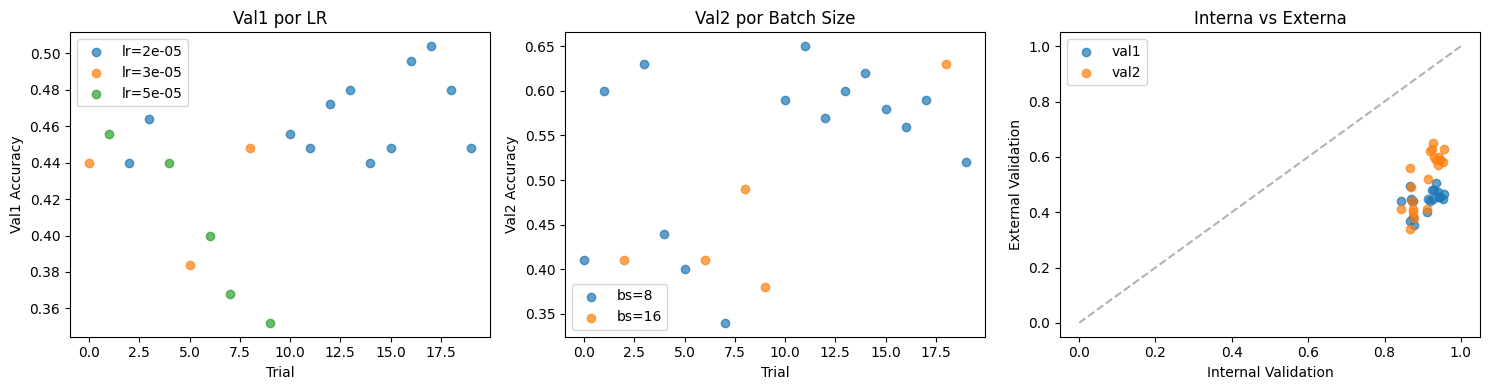

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for lr in sorted(results_df['lr'].unique()):
    mask = results_df['lr'] == lr
    axes[0].scatter(results_df[mask]['trial'], results_df[mask]['val1_acc'], label=f'lr={lr}', alpha=0.7)
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 por LR')
axes[0].legend()

for bs in sorted(results_df['batch_size'].unique()):
    mask = results_df['batch_size'] == bs
    axes[1].scatter(results_df[mask]['trial'], results_df[mask]['val2_acc'], label=f'bs={bs}', alpha=0.7)
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 por Batch Size')
axes[1].legend()

axes[2].scatter(results_df['internal_val'], results_df['val1_acc'], label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'], label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Internal Validation')
axes[2].set_ylabel('External Validation')
axes[2].set_title('Interna vs Externa')
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. Avaliação Detalhada do Melhor Modelo

In [33]:
print('=== Melhor Modelo DistilBERT ===')
for key, value in best_params.items():
    print(f'{key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')

best_model, _, _, best_history, _ = train_bert(
    best_params,
    train_texts,
    train_labels,
    val_texts,
    val_labels,
    tokenizer,
    DEVICE,
)


=== Melhor Modelo DistilBERT ===
lr: 2e-05
batch_size: 8
dropout: 0.1
epochs: 5
max_len: 128
weight_decay: 0.001
freeze_bert: False
Best Internal Validation Accuracy: 0.9553


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



=== Val1 (exemplos) ===
Accuracy: 0.4560

              precision    recall  f1-score   support

   Anthropic       0.50      0.04      0.08        23
      Google       0.23      0.44      0.30        16
       Human       0.55      0.79      0.65        52
        Meta       0.70      0.41      0.52        17
      OpenAI       0.14      0.06      0.08        17

    accuracy                           0.46       125
   macro avg       0.42      0.35      0.33       125
weighted avg       0.46      0.46      0.40       125



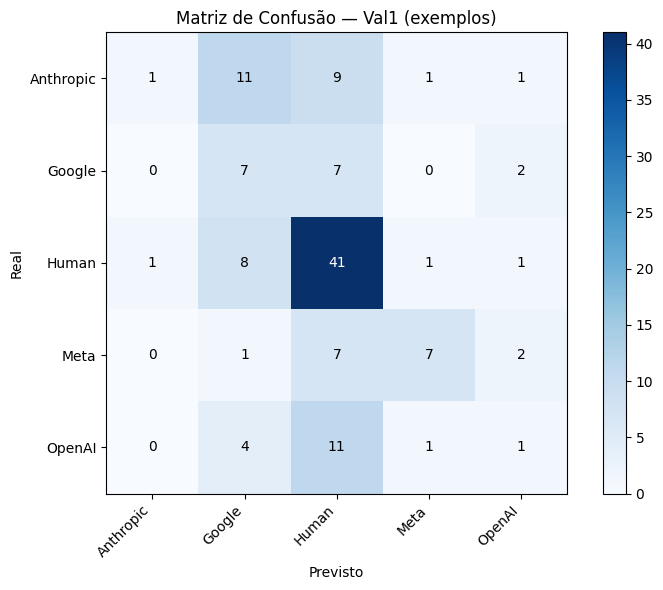


=== Val2 (subm1) ===
Accuracy: 0.6700

              precision    recall  f1-score   support

   Anthropic       0.67      0.24      0.35        17
      Google       0.55      0.65      0.59        17
       Human       0.61      0.91      0.73        34
        Meta       0.94      0.89      0.91        18
      OpenAI       0.83      0.36      0.50        14

    accuracy                           0.67       100
   macro avg       0.72      0.61      0.62       100
weighted avg       0.70      0.67      0.64       100



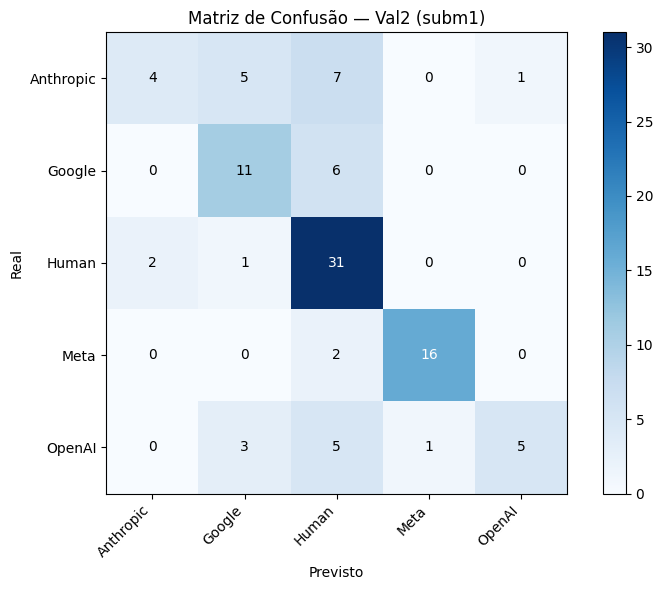

In [34]:
probs_val1, labels_val1 = full_evaluation_bert(
    best_model,
    df_val1['Text'].tolist(),
    df_val1['label_id'].values,
    'Val1 (exemplos)',
    tokenizer,
    best_params['batch_size'],
    best_params['max_len'],
    DEVICE,
)

probs_val2, labels_val2 = full_evaluation_bert(
    best_model,
    df_val2['Text'].tolist(),
    df_val2['label_id'].values,
    'Val2 (subm1)',
    tokenizer,
    best_params['batch_size'],
    best_params['max_len'],
    DEVICE,
)


## 7. Curva ROC (Macro Average)

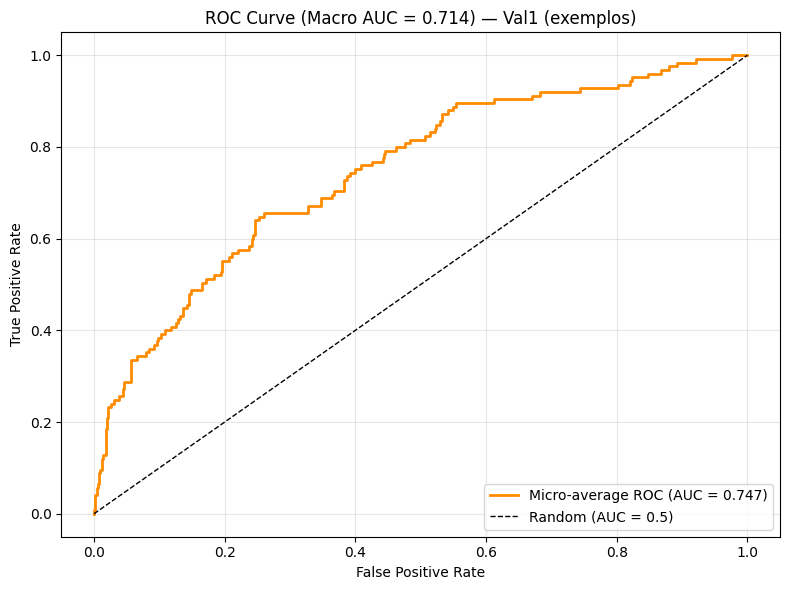

Val1 (exemplos): Micro AUC = 0.7471, Macro AUC = 0.7139


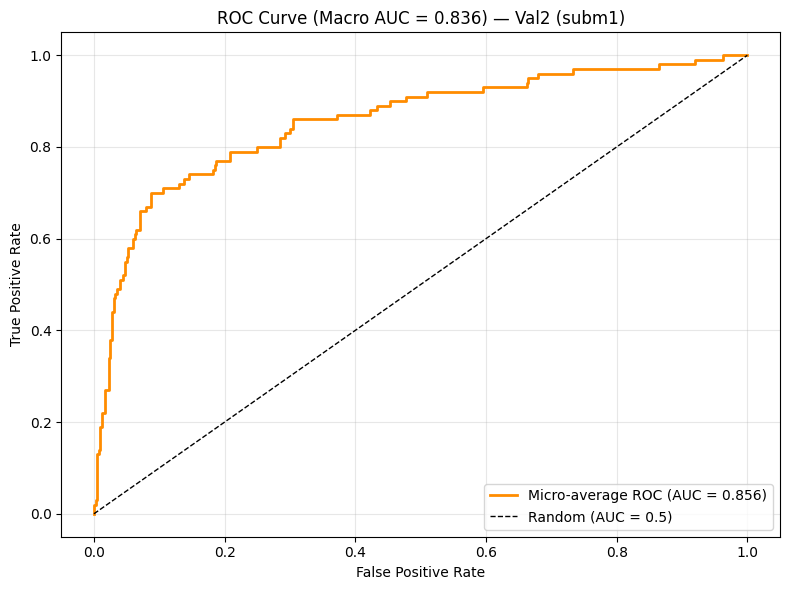

Val2 (subm1): Micro AUC = 0.8563, Macro AUC = 0.8362


In [35]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))

    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)

    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc


macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')


## 8. Conclusões

In [36]:
print('=' * 60)
print('CONCLUSÕES — DistilBERT')
print('=' * 60)
print()

print('Estatísticas por learning rate:')
for lr in sorted(results_df['lr'].unique()):
    mask = results_df['lr'] == lr
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  lr={lr}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print()
print('Melhor configuração:')
for key, value in best_params.items():
    print(f'  {key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
print(f'Val2 Accuracy: {results_df.loc[results_df["internal_val"].idxmax(), "val2_acc"]:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')

results_path = os.path.join(ROOT, 'data', 'processed', 'distilbert_results.csv')
results_df.to_csv(results_path, index=False)
print(f'Resultados guardados em {results_path}')


CONCLUSÕES — DistilBERT

Estatísticas por learning rate:
  lr=2e-05: val1=0.4647 | val2=0.5792
  lr=3e-05: val1=0.4240 | val2=0.4333
  lr=5e-05: val1=0.4032 | val2=0.4340

Melhor configuração:
  lr: 2e-05
  batch_size: 8
  dropout: 0.1
  epochs: 5
  max_len: 128
  weight_decay: 0.001
  freeze_bert: False
Best Internal Validation Accuracy: 0.9553
Val1 AUC (macro): 0.7139
Val2 Accuracy: 0.6300
Val2 AUC (macro): 0.8362
Resultados guardados em /home/joaocunha50/studys/university/MEI/1_ano/AP/Projeto-AP/data/processed/distilbert_results.csv
